In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn import datasets
import pandas as pd

#Discovery Questions; Do weight classes determine fighting style(using clustering), How does reach disadvantage, weight class, and stance determine strike accuracy and bout outcome(Using association technqiue)

#Load and clean data
#the csv borrowed courtesy of komaksym from UFC-DataLab
df = pd.read_csv('stats_reprocessed.csv', sep=';')
df.columns = df.columns.str.strip()
#I made a mistake here. I am keeping it as reference for myself
'''fight_data = df[['winner_name;', 'loser_name;', 'event_date;', 'method;', 'round;', 'time;', 'time_format;', 'bout_type;', 'event_name;', 'event_location;', 'winner_stance;', 'loser_stance;', 'winner;', 'delta_KD;', 'delta_sig_str_pct;', 'delta_total_str_pct;', 'delta_TD_pct;', 'delta_sub_att;', 'delta_rev;', 'delta_ctrl;', 'delta_sig_str_head_acc_pct;', 'delta_sig_str_body_acc_pct;', 'delta_sig_str_leg_acc_pct;', 'delta_sig_str_distance_acc_pct;-', 'delta_sig_str_clinch_acc_pct;', 'delta_sig_str_ground_acc_pct;', 'delta_sig_str_head_tar_pct;', 'delta_sig_str_body_tar_pct;', 'delta_sig_str_leg_tar_pct;', 'delta_sig_str_distance_pos_pct;', 'delta_sig_str_clinch_pos_pct;', 'delta_sig_str_ground_pos_pct;', 'delta_height;', 'delta_reach;', 'delta_slpm_cs;', 'delta_str_acc_cs;', 'delta_sapm_cs;', 'delta_str_def_cs;', 'delta_td_avg_cs;', 'delta_td_acc_cs;', 'delta_td_def_cs;', 'delta_sub_avg_cs;'
]]'''

#List of numerical features you want to analyze
columns_of_interest = ['delta_KD', 'delta_sig_str_pct', 'delta_ctrl']

#Generate summary statistics
#.describe() gives mean, std, min, 25%, 50% (median), 75%, and max
summary_stats = df[columns_of_interest].describe().loc[['mean', '50%', 'std', 'min', 'max']]

#Rename '50%' to 'median' for clarity
summary_stats.rename(index={'50%': 'median'}, inplace=True)

print(summary_stats)

        delta_KD  delta_sig_str_pct   delta_ctrl
mean    0.313338          10.822561   102.317850
median  0.000000          10.000000    38.000000
std     0.668334          20.767206   233.627312
min    -3.000000        -100.000000 -1164.000000
max     5.000000         100.000000  1301.000000


This showcases the main numerical values of mean, median, standard deviation, and as well as the min and max of the data values. 



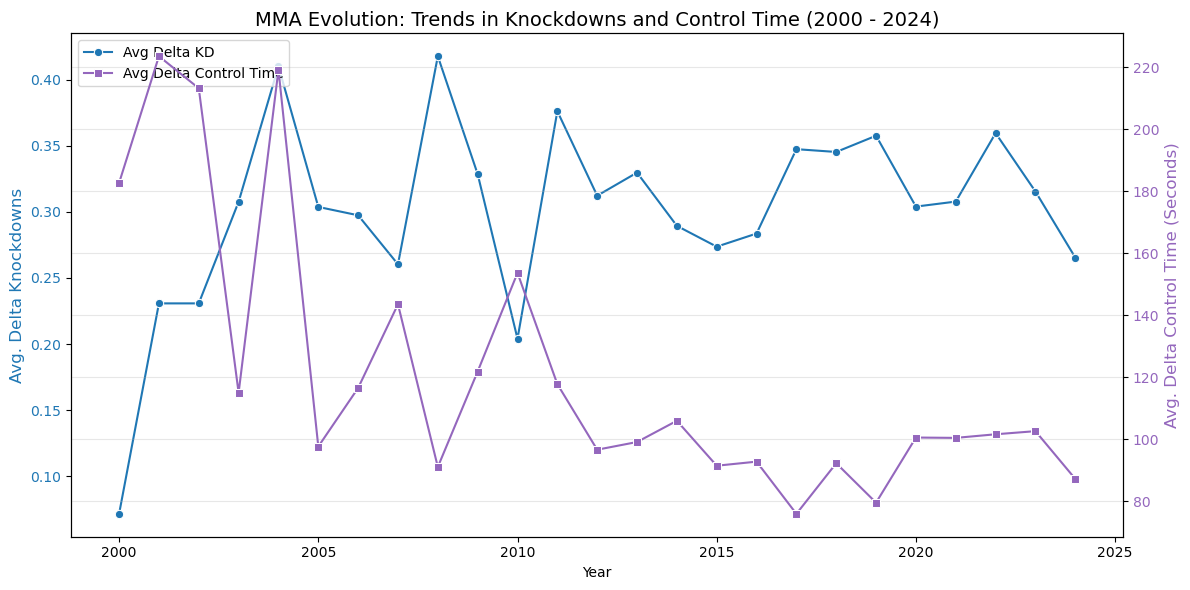

In [6]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn import datasets
import pandas as pd

#Load data
df = pd.read_csv('stats_reprocessed.csv', sep=';')
df.columns = df.columns.str.strip()

#Convert event_date to datetime and extract the Year
df['event_date'] = pd.to_datetime(df['event_date'], dayfirst=True)
df['year'] = df['event_date'].dt.year

#Calculate yearly averages
yearly_stats = df.groupby('year')[['delta_KD', 'delta_ctrl']].mean().reset_index()

#Create a Dual-Axis Line Chart
fig, ax1 = plt.subplots(figsize=(12, 6))

#Plot 1: Knockdowns (Left Y-Axis)
color1 = 'tab:blue'
ax1.set_xlabel('Year')
ax1.set_ylabel('Avg. Delta Knockdowns', color=color1, fontsize=12)
# Set legend=False so Seaborn doesn't create its own legend on this axis
sns.lineplot(data=yearly_stats, x='year', y='delta_KD', ax=ax1, color=color1, 
             marker='o', label='Avg Delta KD', legend=False)
ax1.tick_params(axis='y', labelcolor=color1)

#Plot 2: Control Time (Right Y-Axis)
ax2 = ax1.twinx()
color2 = 'tab:purple'
ax2.set_ylabel('Avg. Delta Control Time (Seconds)', color=color2, fontsize=12)
#Set legend=False here as well
sns.lineplot(data=yearly_stats, x='year', y='delta_ctrl', ax=ax2, color=color2, 
             marker='s', label='Avg Delta Control Time', legend=False)
ax2.tick_params(axis='y', labelcolor=color2)

handler1, label1 = ax1.get_legend_handles_labels()
handler2, label2 = ax2.get_legend_handles_labels()

ax1.legend(handler1 + handler2, label1 + label2, loc='upper left', frameon=True)

plt.title('MMA Evolution: Trends in Knockdowns and Control Time (2000 - 2024)', fontsize=14)
plt.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

This is a temporal graph showing a trend in knockdowns and control time since the 2000s

Fighters in the early 2000s relied on controlling their opponents for minutes at a time, modern fighters separate themselves through impact and damage (knockdowns), as the defensive wrestling of the average fighter has significantly improved, shrinking the control time gap.

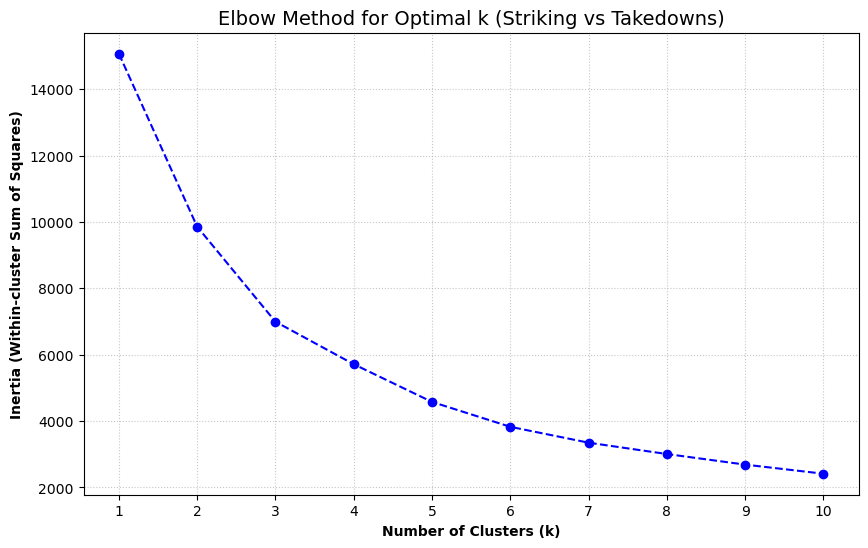

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn import datasets
import pandas as pd

#Discovery Questions; Do weight classes determine fighting style(using clustering), Does having significant reach determine strike accuracy(Using association technqiue)

#Load and clean data
#the csv borrowed courtesy of komaksym from UFC-DataLab
df = pd.read_csv('stats_reprocessed.csv', sep=';')
df.columns = df.columns.str.strip()
#I made a mistake here. I am keeping it as reference for myself
'''fight_data = df[['winner_name;', 'loser_name;', 'event_date;', 'method;', 'round;', 'time;', 'time_format;', 'bout_type;', 'event_name;', 'event_location;', 'winner_stance;', 'loser_stance;', 'winner;', 'delta_KD;', 'delta_sig_str_pct;', 'delta_total_str_pct;', 'delta_TD_pct;', 'delta_sub_att;', 'delta_rev;', 'delta_ctrl;', 'delta_sig_str_head_acc_pct;', 'delta_sig_str_body_acc_pct;', 'delta_sig_str_leg_acc_pct;', 'delta_sig_str_distance_acc_pct;-', 'delta_sig_str_clinch_acc_pct;', 'delta_sig_str_ground_acc_pct;', 'delta_sig_str_head_tar_pct;', 'delta_sig_str_body_tar_pct;', 'delta_sig_str_leg_tar_pct;', 'delta_sig_str_distance_pos_pct;', 'delta_sig_str_clinch_pos_pct;', 'delta_sig_str_ground_pos_pct;', 'delta_height;', 'delta_reach;', 'delta_slpm_cs;', 'delta_str_acc_cs;', 'delta_sapm_cs;', 'delta_str_def_cs;', 'delta_td_avg_cs;', 'delta_td_acc_cs;', 'delta_td_def_cs;', 'delta_sub_avg_cs;'
]]'''


#Filter relevant features and drop NaNs
features = ['delta_sig_str_pct', 'delta_TD_pct']
fight_data = df[features].dropna()

#Preprocess the data
scaler = StandardScaler()
scaled_fights = scaler.fit_transform(fight_data)

#Run KMeans for a range of k values
inertia = []
K_range = range(1, 11)

for k in K_range:
    #Use n_init=10 to suppress warnings and ensure stability
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_fights)
    inertia.append(kmeans.inertia_)

#Plotting the Elbow Method result where the ideal is k = 4
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, marker='o', linestyle='--', color='b')
plt.xlabel('Number of Clusters (k)', fontweight='bold')
plt.ylabel('Inertia (Within-cluster Sum of Squares)', fontweight='bold')
plt.title('Elbow Method for Optimal k (Striking vs Takedowns)', fontsize=14)
plt.xticks(K_range)
plt.grid(True, linestyle=':', alpha=0.7)

plt.show()

This is the elbow method chart showcasing a number of optimal clusters, before utilizing the silhouette technique, 3 seems to show the most significant bend.

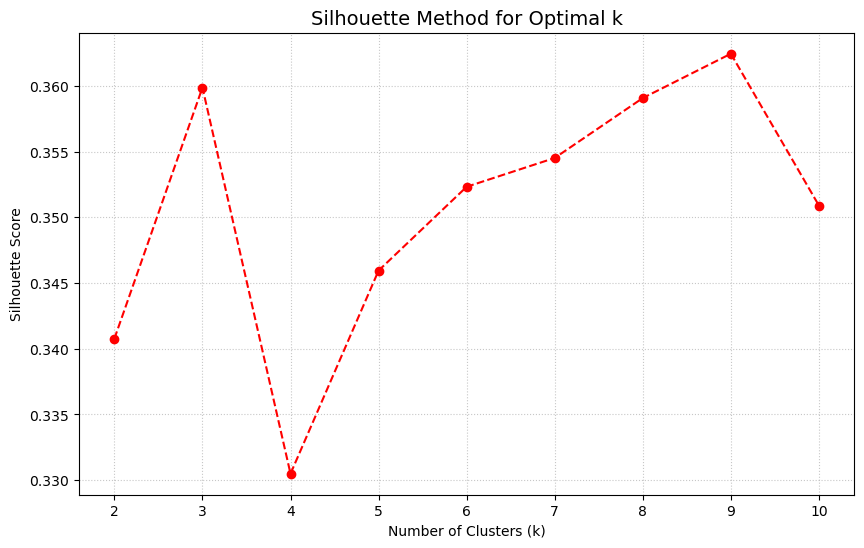

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn import datasets
import pandas as pd
from sklearn.metrics import silhouette_score

#Range of k to test (Silhouette is not defined for k=1)
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(scaled_fights)
    score = silhouette_score(scaled_fights, labels)
    silhouette_scores.append(score)

#Plotting
plt.figure(figsize=(10, 6))
plt.plot(K_range, silhouette_scores, marker='o', linestyle='--', color='r')
plt.title('Silhouette Method for Optimal k', fontsize=14)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

AFter utilizing Silhouette Method to show off the proper K means the two viable options are 3 clusters or 9 clusters. Ultimately 3 was chosen for scalability.

In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn import datasets
import pandas as pd

#Load and Clean
df = pd.read_csv('stats_reprocessed.csv', sep=';')
df.columns = df.columns.str.strip()
features = ['delta_sig_str_pct', 'delta_TD_pct']
df_clean = df.dropna(subset=features).copy()

#Scale and Cluster
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_clean[features])

#defines the variable 'kmeans'
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_clean['cluster'] = kmeans.fit_predict(scaled_data)

#Find Centroids (The "Average" for each cluster)
#These are the scaled coordinates (Z-scores)
centroids_scaled = kmeans.cluster_centers_

#Transform them back to original percentages
centroids_orig = scaler.inverse_transform(centroids_scaled)

#Create a DataFrame and Assign Labels
centroids_df = pd.DataFrame(centroids_orig, columns=features)
centroids_df.index.name = 'Cluster_ID'

#Logic to label each cluster based on its strengths
def label_cluster(row):
    if row['delta_TD_pct'] > 50:
        return "Grappling Dominant"
    elif row['delta_sig_str_pct'] > 20:
        return "Striking Dominant"
    else:
        return "Tactical/Balanced"

centroids_df['Style_Label'] = centroids_df.apply(label_cluster, axis=1)

print("--- Cluster Centroids & Fighting Styles ---")
print(centroids_df)

--- Cluster Centroids & Fighting Styles ---
            delta_sig_str_pct  delta_TD_pct         Style_Label
Cluster_ID                                                     
0                    4.938010     65.513458  Grappling Dominant
1                    2.478224    -20.240667   Tactical/Balanced
2                   39.222366     24.739496   Striking Dominant


These are the centroid datas in the clusters showcasing which style belongs in which cluster. 

0 showcasing grappling dominant styles 
1 showcasing balanced or tactical style which utilize both styles equally
2 showcasing striking dominant styles

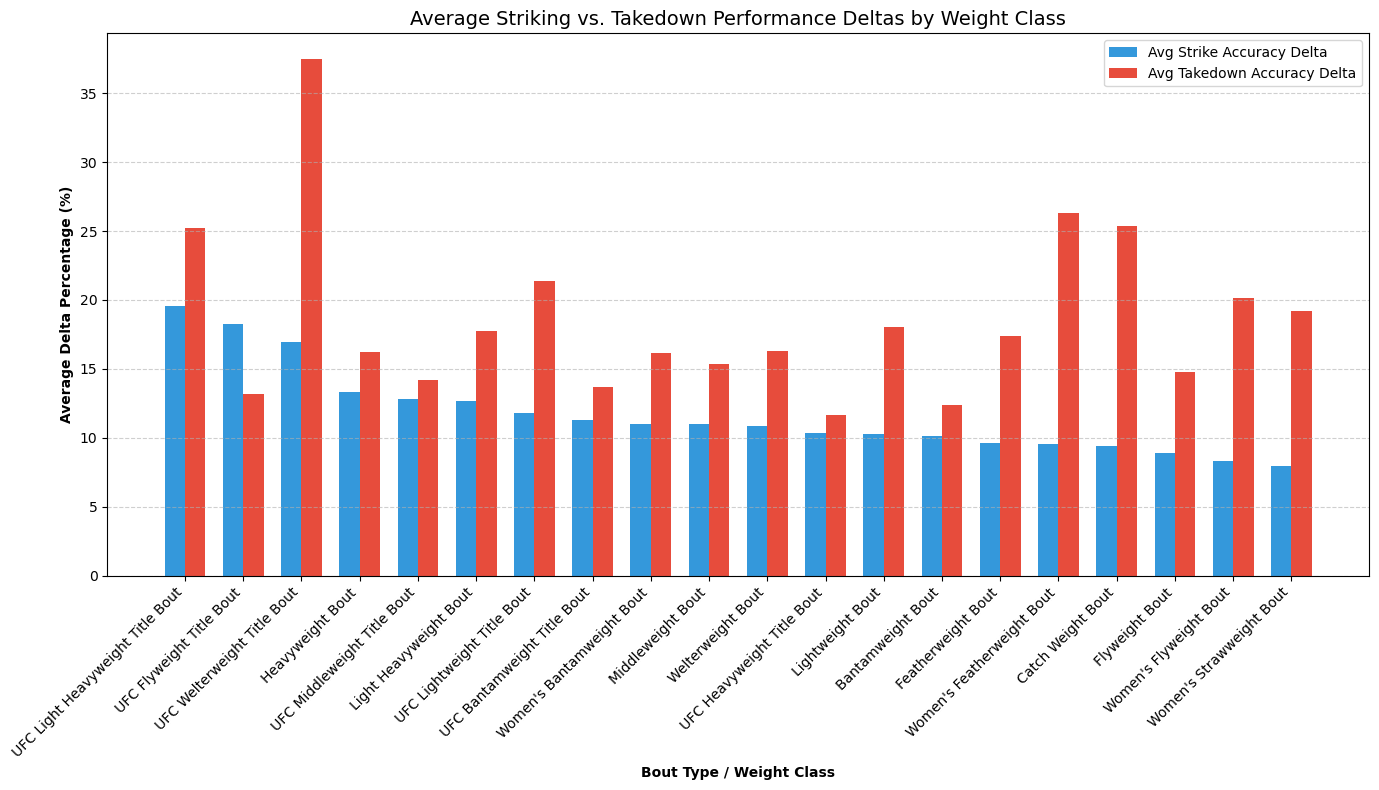

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn import datasets
import pandas as pd

#Load data
#the csv borrowed courtesy of komaksym from UFC-DataLab
df = pd.read_csv('stats_reprocessed.csv', sep=';')
df.columns = df.columns.str.strip()

#Group by bout_type and calculate average deltas
#filter for types with at least 20 fights to avoid outliers from rare bout types
bout_counts = df['bout_type'].value_counts()
common_bouts = bout_counts[bout_counts > 20].index
avg_stats = df[df['bout_type'].isin(common_bouts)].groupby('bout_type')[['delta_sig_str_pct', 'delta_TD_pct']].mean()

#Sort by striking delta for better visualization flow
avg_stats = avg_stats.sort_values(by='delta_sig_str_pct', ascending=False)

#Create the Bar Graph
plt.figure(figsize=(14, 8))
x = np.arange(len(avg_stats.index))
width = 0.35

plt.bar(x - width/2, avg_stats['delta_sig_str_pct'], width, label='Avg Strike Accuracy Delta', color='#3498db')
plt.bar(x + width/2, avg_stats['delta_TD_pct'], width, label='Avg Takedown Accuracy Delta', color='#e74c3c')

#Formatting the plot
plt.xlabel('Bout Type / Weight Class', fontweight='bold')
plt.ylabel('Average Delta Percentage (%)', fontweight='bold')
plt.title('Average Striking vs. Takedown Performance Deltas by Weight Class', fontsize=14)
plt.xticks(x, avg_stats.index, rotation=45, ha='right')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In the bar chart it showcases that almost every style with the exception of flyweight title bouts have higher takedown averages with some lighter weight classes having a greater difference in strike accuracy to takedown attempts while as the weight classes get heavier it begins to equal out a bit while still leaning in favor of takedown attempts. 

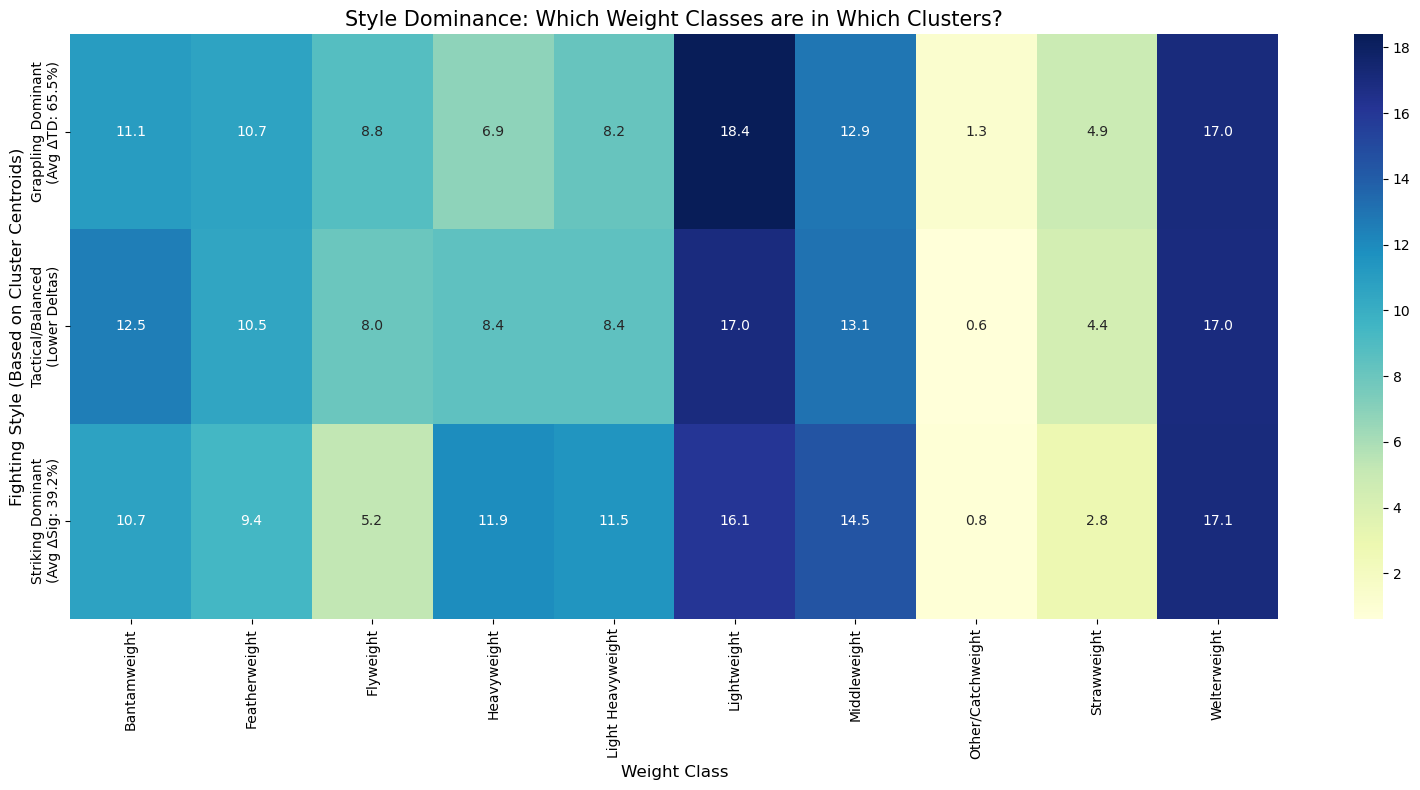

In [4]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn import datasets
import pandas as pd

#Load Data
#the csv borrowed courtesy of komaksym from UFC-DataLab
df = pd.read_csv('stats_reprocessed.csv', sep=';')
df.columns = df.columns.str.strip()

features = ['delta_sig_str_pct', 'delta_TD_pct']
df_clean = df.dropna(subset=features).copy()

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_clean[features])
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_clean['cluster'] = kmeans.fit_predict(scaled_data)

#Simplify Bout Types to Weight Classes
def simplify_bout(bout):
    bout = str(bout).lower()
    if 'light heavyweight' in bout: return 'Light Heavyweight'
    if 'heavyweight' in bout: return 'Heavyweight'
    if 'middleweight' in bout: return 'Middleweight'
    if 'welterweight' in bout: return 'Welterweight'
    if 'lightweight' in bout: return 'Lightweight'
    if 'featherweight' in bout: return 'Featherweight'
    if 'bantamweight' in bout: return 'Bantamweight'
    if 'flyweight' in bout: return 'Flyweight'
    if 'strawweight' in bout: return 'Strawweight'
    return 'Other/Catchweight'

df_clean['weight_class'] = df_clean['bout_type'].apply(simplify_bout)

#Create a Composition Matrix (normalize by 'index' to see % of cluster)
cluster_composition = pd.crosstab(df_clean['cluster'], df_clean['weight_class'], normalize='index') * 100

#Get Centroids and Create Descriptive Labels
#Inverse transform to get the real percentage values
centroids_orig = scaler.inverse_transform(kmeans.cluster_centers_)

def create_label(row):
    sig_delta = row[0]
    td_delta = row[1]
    if td_delta > 50:
        return f"Grappling Dominant\n(Avg ΔTD: {td_delta:.1f}%)"
    elif sig_delta > 20:
        return f"Striking Dominant\n(Avg ΔSig: {sig_delta:.1f}%)"
    else:
        return f"Tactical/Balanced\n(Lower Deltas)"

#Create a mapping dictionary: {0: 'Label 0', 1: 'Label 1', ...}
cluster_labels = {i: create_label(centroids_orig[i]) for i in range(len(centroids_orig))}

#Create the Composition Matrix as you did before
cluster_composition = pd.crosstab(df_clean['cluster'], df_clean['weight_class'], normalize='index') * 100

#Rename the Index of the matrix using your labels
cluster_composition.index = cluster_composition.index.map(cluster_labels)

#Plot Heatmap
plt.figure(figsize=(16, 8))
sns.heatmap(cluster_composition, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title('Style Dominance: Which Weight Classes are in Which Clusters?', fontsize=15)
plt.ylabel('Fighting Style (Based on Cluster Centroids)', fontsize=12)
plt.xlabel('Weight Class', fontsize=12)
plt.tight_layout()
plt.show()

This is the heatmap that showcases what fighting style belongs within which centroid. The interesting discovery listed here is that lighter weight classes such as Bantamweight, lightweight, and even welterweight seems to equalize out indicating these weight classes are tactically diverse. Whereas heavier weight classes start leaning in favor of striking dominant styles.

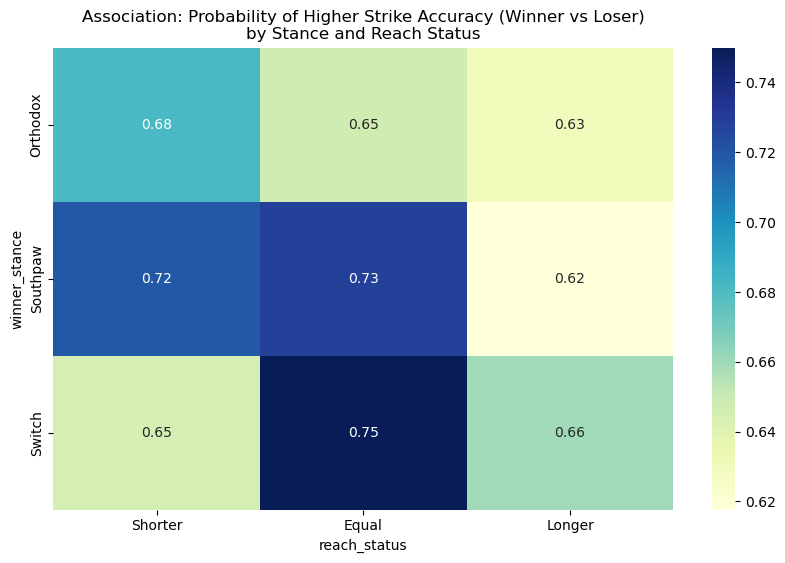

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#Load the dataset 
df = pd.read_csv('stats_processed.csv', sep=';')

#Preprocessing: Standardizing Weight Classes
def get_weight_class(bout):
    bout = str(bout).lower()
    classes = ['flyweight', 'bantamweight', 'featherweight', 'lightweight', 
               'welterweight', 'middleweight', 'light heavyweight', 'heavyweight', 'strawweight']
    for c in classes:
        if c in bout:
            return c.title()
    return 'Other'

df['weight_class'] = df['bout_type'].apply(get_weight_class)

#Categorizing Performance Metrics
#Shorter: winner had less reach. Equal: same reach. Longer: winner had more reach.
df['reach_status'] = pd.cut(df['delta_reach'], 
                             bins=[-np.inf, -0.1, 0.1, np.inf], 
                             labels=['Shorter', 'Equal', 'Longer'])

#Higher: winner out-landed opponent in % accuracy.
df['acc_status'] = pd.cut(df['delta_sig_str_pct'], 
                            bins=[-np.inf, -2, 2, np.inf], 
                            labels=['Lower Accuracy', 'Similar', 'Higher Accuracy'])

#Filter for the most common stances and major weight classes
major_classes = ['Flyweight', 'Bantamweight', 'Featherweight', 'Lightweight', 
                 'Welterweight', 'Middleweight', 'Light Heavyweight', 'Heavyweight']
major_stances = ['Orthodox', 'Southpaw', 'Switch']

eda_df = df[(df['weight_class'].isin(major_classes)) & 
            (df['winner_stance'].isin(major_stances))].dropna(subset=['reach_status', 'acc_status']).copy()

#Accuracy Association
#We calculate the probability of the winner having "Higher Accuracy" 
#given their stance and reach status.
acc_prob = eda_df.groupby(['winner_stance', 'reach_status'], observed=True)['acc_status'] \
                 .value_counts(normalize=True).unstack().reset_index()

pivot_acc = acc_prob.pivot(index='winner_stance', columns='reach_status', values='Higher Accuracy')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_acc, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Association: Probability of Higher Strike Accuracy (Winner vs Loser)\nby Stance and Reach Status')
plt.show()

The dataset I am taking this from is already preprocessed for missing datasets I am filtering through with the code. 

From what is seen on the heat map visualization 

In answering my question Southpaw and Orthodox have similar distributions in reach teetering between shorter or equal whereas switch differs by having a high density in equal length (within 2 inches difference)

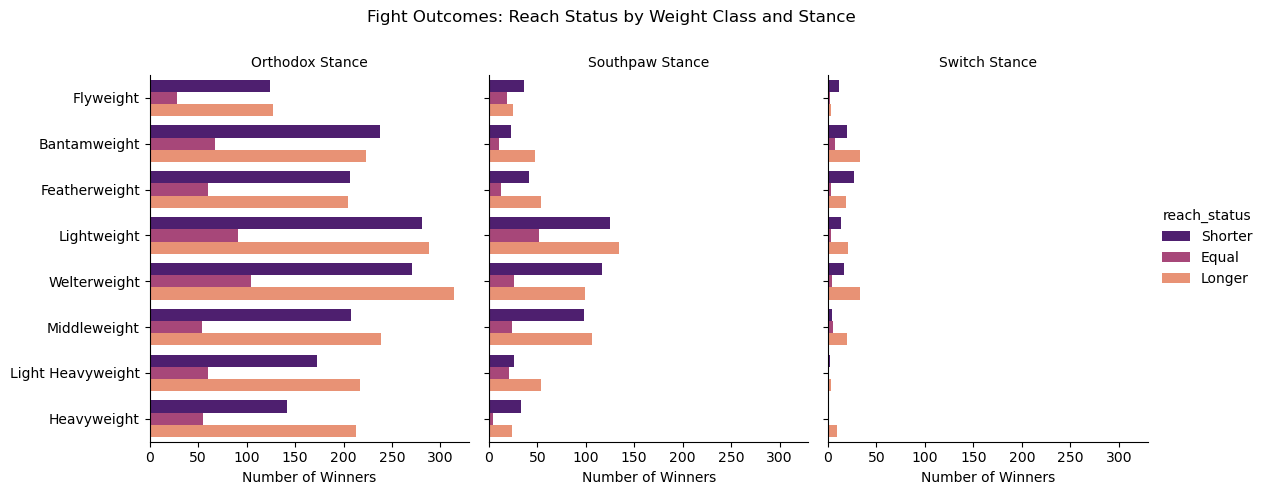

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#Load the dataset
df = pd.read_csv('stats_processed.csv', sep=';')

#Preprocessing: Standardizing Weight Classes
def get_weight_class(bout):
    bout = str(bout).lower()
    classes = ['flyweight', 'bantamweight', 'featherweight', 'lightweight', 
               'welterweight', 'middleweight', 'light heavyweight', 'heavyweight', 'strawweight']
    for c in classes:
        if c in bout:
            return c.title()
    return 'Other'

df['weight_class'] = df['bout_type'].apply(get_weight_class)

#Categorizing Performance Metrics
# Shorter: winner had less reach. Equal: same reach. Longer: winner had more reach.
df['reach_status'] = pd.cut(df['delta_reach'], 
                             bins=[-np.inf, -0.1, 0.1, np.inf], 
                             labels=['Shorter', 'Equal', 'Longer'])

#Higher: winner out-landed opponent in % accuracy.
df['acc_status'] = pd.cut(df['delta_sig_str_pct'], 
                            bins=[-np.inf, -2, 2, np.inf], 
                            labels=['Lower Accuracy', 'Similar', 'Higher Accuracy'])

#Filter for the most common stances and major weight classes
major_classes = ['Flyweight', 'Bantamweight', 'Featherweight', 'Lightweight', 
                 'Welterweight', 'Middleweight', 'Light Heavyweight', 'Heavyweight']
major_stances = ['Orthodox', 'Southpaw', 'Switch']

eda_df = df[(df['weight_class'].isin(major_classes)) & 
            (df['winner_stance'].isin(major_stances))].dropna(subset=['reach_status', 'acc_status']).copy()

#Fight Outcomes
# This shows how often shorter vs longer fighters win across different categories
g = sns.catplot(
    data=eda_df, 
    y='weight_class',      #Move Weight Class here
    hue='reach_status', 
    col='winner_stance', 
    kind='count', 
    order=major_classes,   #Keeps them in standard weight order
    height=5, 
    aspect=0.8, 
    palette='magma',
    sharey=True
)
g.set_axis_labels("Number of Winners", "")
g.set_titles("{col_name} Stance")
plt.subplots_adjust(top=0.85)
g.fig.suptitle('Fight Outcomes: Reach Status by Weight Class and Stance')
plt.show()

While the majority of the datasets are in orthodox stance by weight classes it showcases that each weight class has equal distributions of twin peak graphs almost equalizing between short reach and long reach. While switch stance winners are often longer in certain weight brackets showing they may potentially rely on having a reach advantage. 

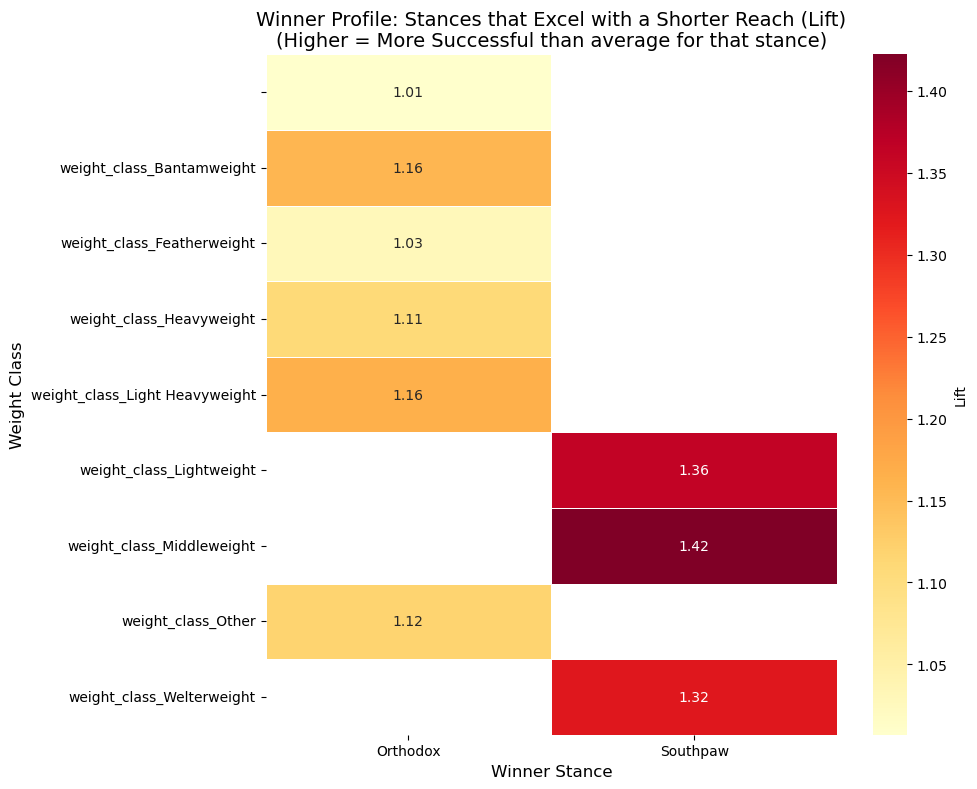

In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mlxtend.frequent_patterns import apriori, association_rules

#Load and Preprocess
df = pd.read_csv('stats_processed.csv', sep=';')

def get_weight_class(bout):
    classes = ['Flyweight', 'Bantamweight', 'Featherweight', 'Lightweight', 
               'Welterweight', 'Middleweight', 'Light Heavyweight', 'Heavyweight']
    for c in classes:
        if c in str(bout): return c
    return 'Other'

df['weight_class'] = df['bout_type'].apply(get_weight_class)

#Create Categorical Bins (Shorter_Reach is delta_reach < -0.1)
df['reach_status'] = pd.cut(df['delta_reach'], 
                            bins=[-np.inf, -0.1, 0.1, np.inf], 
                            labels=['Shorter_Reach', 'Equal_Reach', 'Longer_Reach'])

#Prepare the Basket
basket_df = df[['weight_class', 'winner_stance', 'reach_status']].dropna()

basket_sets = pd.get_dummies(basket_df)

#Apply Apriori
frequent_itemsets = apriori(basket_sets, min_support=0.005, use_colnames=True)

#Create Association Rules
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)

#Clean strings
rules['antecedents_str'] = rules['antecedents'].apply(lambda x: ', '.join(list(x)))
rules['consequents_str'] = rules['consequents'].apply(lambda x: ', '.join(list(x)))

#Focus only on winners with Shorter_Reach and specific Stances
#We look for rules where Shorter_Reach is in the condition (antecedent) 
#and the Stance is the outcome (consequent).
stances = ['winner_stance_Orthodox', 'winner_stance_Southpaw', 'winner_stance_Switch']
shorter_reach_rules = rules[
    (rules['antecedents_str'].str.contains('Shorter_Reach')) & 
    (rules['consequents_str'].isin(stances))
].copy()

#Clean the row labels (Remove "reach_status_Shorter_Reach" from the Y-axis names)
shorter_reach_rules['Weight_Class'] = shorter_reach_rules['antecedents_str'].str.replace(',? ?reach_status_Shorter_Reach', '', regex=True)
shorter_reach_rules['Stance'] = shorter_reach_rules['consequents_str'].str.replace('winner_stance_', '')

#Pivot for the Heatmap
pivot_shorter = shorter_reach_rules.pivot_table(index='Weight_Class', columns='Stance', values='lift')

#Plotting
plt.figure(figsize=(10, 8))
sns.heatmap(pivot_shorter, annot=True, cmap='YlOrRd', fmt='.2f', linewidths=.5, cbar_kws={'label': 'Lift'})

plt.title('Winner Profile: Stances that Excel with a Shorter Reach (Lift)\n(Higher = More Successful than average for that stance)', fontsize=14)
plt.ylabel('Weight Class', fontsize=12)
plt.xlabel('Winner Stance', fontsize=12)
plt.tight_layout()
plt.show()

In this heatmap specifically examining weight class, shorter reach, and stance. For Orthodox having a shorter reach doesn't affect the outcome of a bout but on the other hand, southpaw stance for lightweight, welterweight, and middle weight have higher rates of winning if they have a shorter reach. 

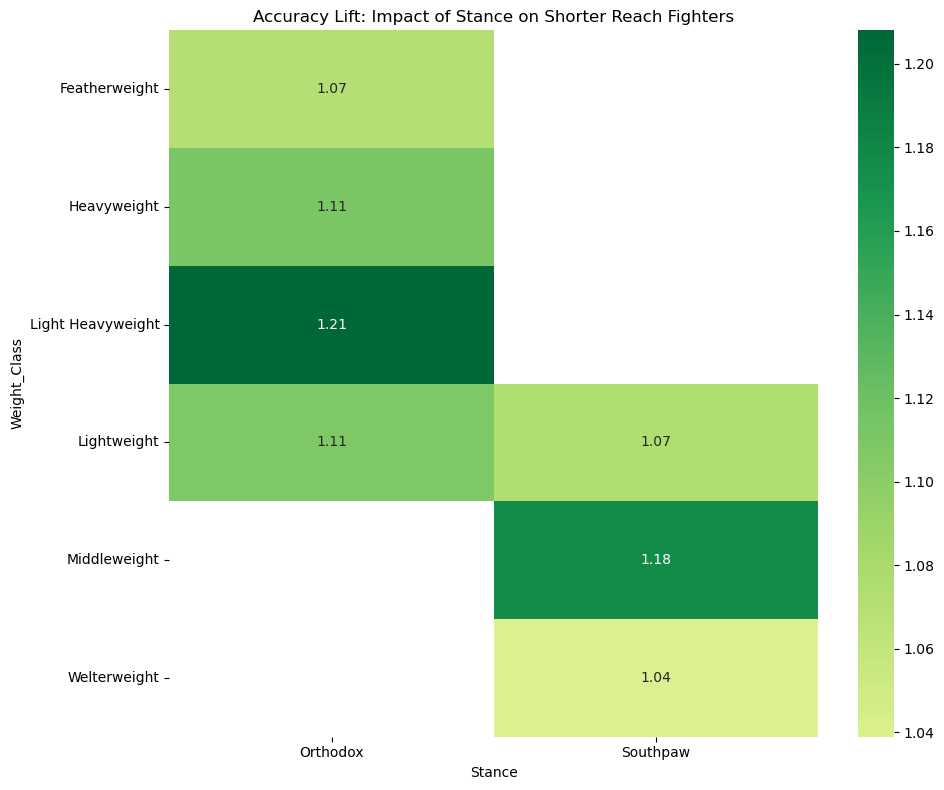

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mlxtend.frequent_patterns import apriori, association_rules

#Load Data
df = pd.read_csv('stats_processed.csv', sep=';')

accuracy_col = 'delta_sig_str_pct'

#Ensure the column is a float (handles cases where data is '45%')
if df[accuracy_col].dtype == 'object':
    df[accuracy_col] = df[accuracy_col].str.replace('%', '').astype(float)
    # If the values were like 45.0 instead of 0.45, normalize them:
    if df[accuracy_col].max() > 1:
        df[accuracy_col] = df[accuracy_col] / 100

#Preprocessing
def get_weight_class(bout):
    classes = ['Flyweight', 'Bantamweight', 'Featherweight', 'Lightweight', 
               'Welterweight', 'Middleweight', 'Light Heavyweight', 'Heavyweight']
    for c in classes:
        if c in str(bout): return c
    return 'Other'

df['weight_class'] = df['bout_type'].apply(get_weight_class)

#Define High Accuracy and Reach Status
df['high_accuracy'] = df[accuracy_col] > df[accuracy_col].median()
df['reach_status'] = pd.cut(df['delta_reach'], 
                            bins=[-np.inf, -0.1, 0.1, np.inf], 
                            labels=['Shorter_Reach', 'Equal_Reach', 'Longer_Reach'])

#Prepare the Basket
stance_col = 'winner_stance' if 'winner_stance' in df.columns else 'stance'

basket_df = df[['weight_class', stance_col, 'reach_status', 'high_accuracy']].dropna()
basket_sets = pd.get_dummies(basket_df, columns=['weight_class', stance_col, 'reach_status'])
basket_sets['high_accuracy'] = basket_sets['high_accuracy'].astype(bool)

#Association Rules
frequent_itemsets = apriori(basket_sets, min_support=0.005, use_colnames=True)
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)

#Filtering for Heatmap
accuracy_rules = rules[rules['consequents'].apply(lambda x: 'high_accuracy' in x)].copy()
accuracy_rules['antecedents_str'] = accuracy_rules['antecedents'].apply(lambda x: ', '.join(list(x)))

#Focus on Shorter Reach
final_rules = accuracy_rules[accuracy_rules['antecedents_str'].str.contains('Shorter_Reach')].copy()

final_rules['Weight_Class'] = final_rules['antecedents_str'].str.extract(r'weight_class_([^,]+)')
final_rules['Stance'] = final_rules['antecedents_str'].str.extract(fr'{stance_col}_([^,]+)')

#Pivot and Plot
pivot_accuracy = final_rules.pivot_table(index='Weight_Class', columns='Stance', values='lift')

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_accuracy, annot=True, cmap='RdYlGn', center=1.0, fmt='.2f')
plt.title('Accuracy Lift: Impact of Stance on Shorter Reach Fighters')
plt.tight_layout()
plt.show()

In the heatmap above while the weight classes that significantly lean in favor of shorter reach to give high accuracy is light heavyweight for orthodox and middleweight for southpaw showcasing that these weight classes perform better with their respective stance of Orthodox Light Heavyweight and Southpaw middleweight fighters. 